In [1]:
import sys
import os
from pathlib import Path

# 获取 backtest 文件夹的绝对路径
# 方法1: 如果 notebook 在 backtest 文件夹内，当前目录就是 backtest
# 方法2: 如果 notebook 在项目根目录，需要添加 backtest 到路径
project_root = Path.cwd()

# 检查 backtest 文件夹是否存在
backtest_dir = project_root / 'backtest'
if backtest_dir.exists() and (backtest_dir / 'backtesting.py').exists():
    # backtest 是子文件夹
    if str(backtest_dir) not in sys.path:
        sys.path.insert(0, str(backtest_dir))
    print(f"使用子文件夹: {backtest_dir}")
elif (project_root / 'backtesting.py').exists():
    # backtesting.py 在当前目录（说明当前目录就是 backtest）
    print(f"使用当前目录: {project_root}")
else:
    # 尝试使用当前目录作为 backtest
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    print(f"尝试使用当前目录: {project_root}")

# 重新加载模块（如果修改了 backtesting.py，需要重新加载）
import importlib
if 'backtesting' in sys.modules:
    importlib.reload(sys.modules['backtesting'])

from backtesting import SimpleBacktester
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 验证方法是否存在
print("\n库导入成功！")
print(f"当前工作目录: {os.getcwd()}")
print(f"display_results 方法存在: {hasattr(SimpleBacktester, 'display_results')}")
print(f"plot_equity 方法存在: {hasattr(SimpleBacktester, 'plot_equity')}")
print(f"batch_run 方法存在: {hasattr(SimpleBacktester, 'batch_run')}")


使用当前目录: d:\FREML\project\backtest

库导入成功！
当前工作目录: d:\FREML\project\backtest
display_results 方法存在: True
plot_equity 方法存在: True
batch_run 方法存在: True


d:\FREML\project\backtest\backtesting.py:15: UserWarning: Optuna not installed. Optimization features will be disabled.
  warnings.warn("Optuna not installed. Optimization features will be disabled.")


In [2]:
np.random.seed(42)

# 生成 1000 天的 Lead 价格数据（模拟 LME Lead 期货价格）
n_days = 1000
dates = pd.date_range(start="2020-01-01", periods=n_days, freq='D')

# 使用随机游走 + 趋势模拟价格
initial_price = 2000  # 初始价格 $2000/吨（Lead 的典型价格范围）
trend = np.linspace(0, 0.2, n_days)  # 轻微上涨趋势
noise = np.random.normal(0, 0.015, n_days)  # 日波动约 1.5%
returns = trend / n_days + noise

# 生成价格序列
prices = initial_price * (1 + pd.Series(returns)).cumprod()
prices.index = dates
prices.name = "Lead_Price"

print(f"价格数据范围: {prices.min():.2f} - {prices.max():.2f}")
print(f"价格数据长度: {len(prices)} 天")
print(f"\n价格数据前5天:")
print(prices.head())
print(f"\n价格数据后5天:")
print(prices.tail())


价格数据范围: 1518.75 - 2994.16
价格数据长度: 1000 天

价格数据前5天:
2020-01-01    2014.901425
2020-01-02    2010.722994
2020-01-03    2030.258633
2020-01-04    2076.642020
2020-01-05    2069.349892
Freq: D, Name: Lead_Price, dtype: float64

价格数据后5天:
2022-09-22    2556.179423
2022-09-23    2625.617263
2022-09-24    2651.380457
2022-09-25    2629.194010
2022-09-26    2652.301317
Freq: D, Name: Lead_Price, dtype: float64


In [3]:
# 生成简单的移动平均策略信号
# 策略：当价格高于长期均线时做多，低于时做空
short_window = 10
long_window = 30

ma_short = prices.rolling(short_window).mean()
ma_long = prices.rolling(long_window).mean()

# 信号：价格相对均线的偏离程度，归一化到 [-1, 1]
signal = (prices - ma_long) / ma_long
signal = signal.clip(-1, 1).fillna(0)

print(f"信号范围: {signal.min():.3f} - {signal.max():.3f}")
print(f"\n信号统计:")
print(signal.describe())
print(f"\n信号前10天:")
print(signal.head(10))


信号范围: -0.099 - 0.157

信号统计:
count    1000.000000
mean        0.004977
std         0.045045
min        -0.098660
25%        -0.025349
50%         0.000099
75%         0.030336
max         0.156751
Name: Lead_Price, dtype: float64

信号前10天:
2020-01-01    0.0
2020-01-02    0.0
2020-01-03    0.0
2020-01-04    0.0
2020-01-05    0.0
2020-01-06    0.0
2020-01-07    0.0
2020-01-08    0.0
2020-01-09    0.0
2020-01-10    0.0
Freq: D, Name: Lead_Price, dtype: float64


In [4]:
# 创建回测器并运行回测
# 设置手续费率：0.05% (5bp)，这是大宗商品期货的典型费率
bt = SimpleBacktester(
    prices=prices,
    fee_rate=0.0005,  # 0.05% 手续费
    name="Lead MA Strategy",
    trading_days=252
)

# 运行回测
result = bt.run(signal)

print("回测完成！")
print(f"回测天数: {result.stats.n_days}")
print(f"总收益: {result.stats.total_return:.2%}")


回测完成！
回测天数: 1000
总收益: -0.47%


In [5]:
# 显示详细回测结果
SimpleBacktester.display_results(result)



回测结果: BacktestStats(total_return=-0.0046966915219109895, annual_return=-0.0011856509796374093, annual_vol=0.010385238359662968, sharpe=-0.11416694914221374, max_drawdown=-0.030606560237186997, avg_turnover=0.011295769778101799, n_days=1000, annual_return_gross=0.00023698516228298772, annual_vol_gross=0.010381237921758022, sharpe_gross=0.022828217989907622, max_drawdown_gross=-0.025960522705130606, margin=0.034910471094635465, calmar_ratio=-0.03873845902476954, sortino_ratio=-0.14985681012386387, win_rate=0.462, profit_loss_ratio=1.0759507404739408, max_consecutive_losses=9, max_consecutive_wins=8)

【核心指标】
  总收益: -0.47%
  年化收益 (Net/Gross): -0.12% / 0.02%
  年化波动率 (Net/Gross): 1.04% / 1.04%
  Sharpe 比率 (Net/Gross): -0.114 / 0.023
  最大回撤 (Net/Gross): -3.06% / -2.60%

【风险指标】
  Calmar 比率: -0.039
  Sortino 比率: -0.150
  最大连续亏损: 9 天
  最大连续盈利: 8 天

【交易统计】
  胜率: 46.20%
  盈亏比: 1.076
  平均换手率: 0.0113
  保证金占用: 3.49%
  回测天数: 1000


In [6]:
# 查看汇总统计（字典格式）
summary = SimpleBacktester.summarize(result)
print("\n汇总统计（字典格式）:")
for key, value in summary.items():
    if isinstance(value, float):
        if 'Return' in key or 'Drawdown' in key or 'Vol' in key or 'Margin' in key:
            print(f"  {key}: {value:.2%}")
        elif 'Ratio' in key or 'Sharpe' in key or 'Rate' in key:
            print(f"  {key}: {value:.3f}")
        else:
            print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")



汇总统计（字典格式）:
  Total Return: -0.47%
  Annual Return (Net): -0.12%
  Annual Return (Gross): 0.02%
  Annual Vol (Net): 1.04%
  Annual Vol (Gross): 1.04%
  Sharpe (Net): -0.114
  Sharpe (Gross): 0.023
  Max Drawdown (Net): -3.06%
  Max Drawdown (Gross): -2.60%
  Calmar Ratio: -0.039
  Sortino Ratio: -0.150
  Win Rate: 0.462
  Profit/Loss Ratio: 1.076
  Max Consecutive Losses: 9
  Max Consecutive Wins: 8
  Avg Turnover: 0.0113
  Margin: 3.49%
  N Days: 1000


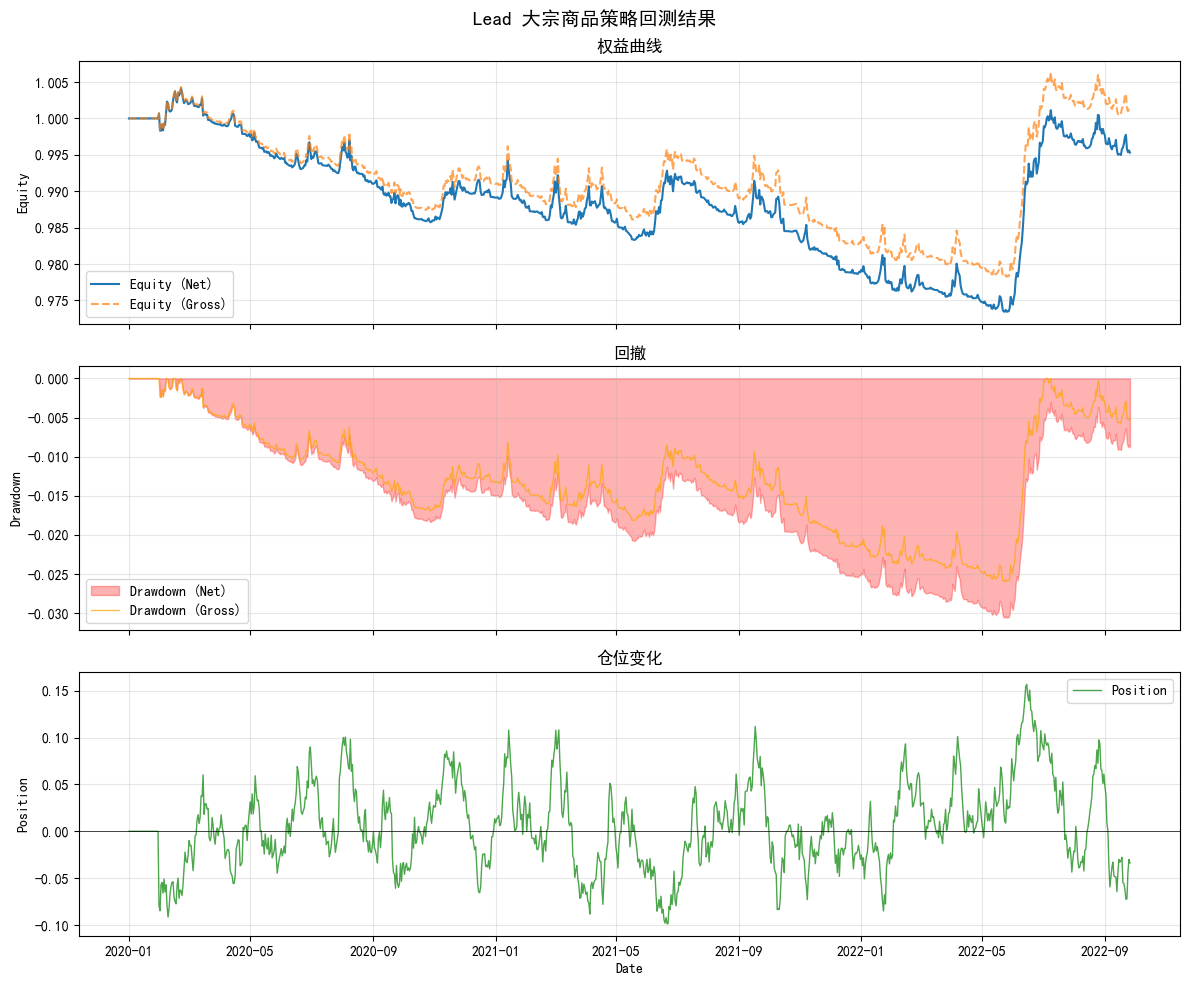

In [7]:
# 绘制回测结果图表
SimpleBacktester.plot_equity(
    result, 
    title="Lead 大宗商品策略回测结果",
    show_gross=True
)


In [8]:
# 测试批量回测功能 - 对比多个策略
# 策略1: 短期均线策略
signal1 = (prices - ma_short) / ma_short
signal1 = signal1.clip(-1, 1).fillna(0)

# 策略2: 长期均线策略（已有）
signal2 = signal.copy()

# 策略3: 随机信号（作为基准对比）
np.random.seed(123)
signal3 = pd.Series(np.random.uniform(-0.5, 0.5, len(prices)), index=prices.index)

# 创建多个回测器
bt1 = SimpleBacktester(prices, fee_rate=0.0005, name="短期MA策略")
bt2 = SimpleBacktester(prices, fee_rate=0.0005, name="长期MA策略")
bt3 = SimpleBacktester(prices, fee_rate=0.0005, name="随机策略")

# 批量回测
batch_result = SimpleBacktester.batch_run(
    backtesters=[bt1, bt2, bt3],
    signals=[signal1, signal2, signal3],
    names=["短期MA策略", "长期MA策略", "随机策略"]
)

# 显示对比结果
SimpleBacktester.display_results(batch_result)



批量回测结果对比

Strategy  Total Return  Annual Return (Net)  Annual Return (Gross)  Sharpe (Net)  Sharpe (Gross)  Max Drawdown (Net)  Max Drawdown (Gross)  Calmar Ratio  Sortino Ratio  Win Rate  Avg Turnover   Margin
  短期MA策略     -0.008180            -0.002068              -0.000678     -0.362552       -0.118991           -0.019990             -0.015235     -0.103438      -0.470355     0.456      0.011042 0.019125
  长期MA策略     -0.004697            -0.001186               0.000237     -0.114167        0.022828           -0.030607             -0.025961     -0.038738      -0.149857     0.462      0.011296 0.034910
    随机策略      0.015522             0.003889               0.047176      0.059267        0.718018           -0.131472             -0.104321      0.029580       0.084501     0.487      0.335117 0.244648


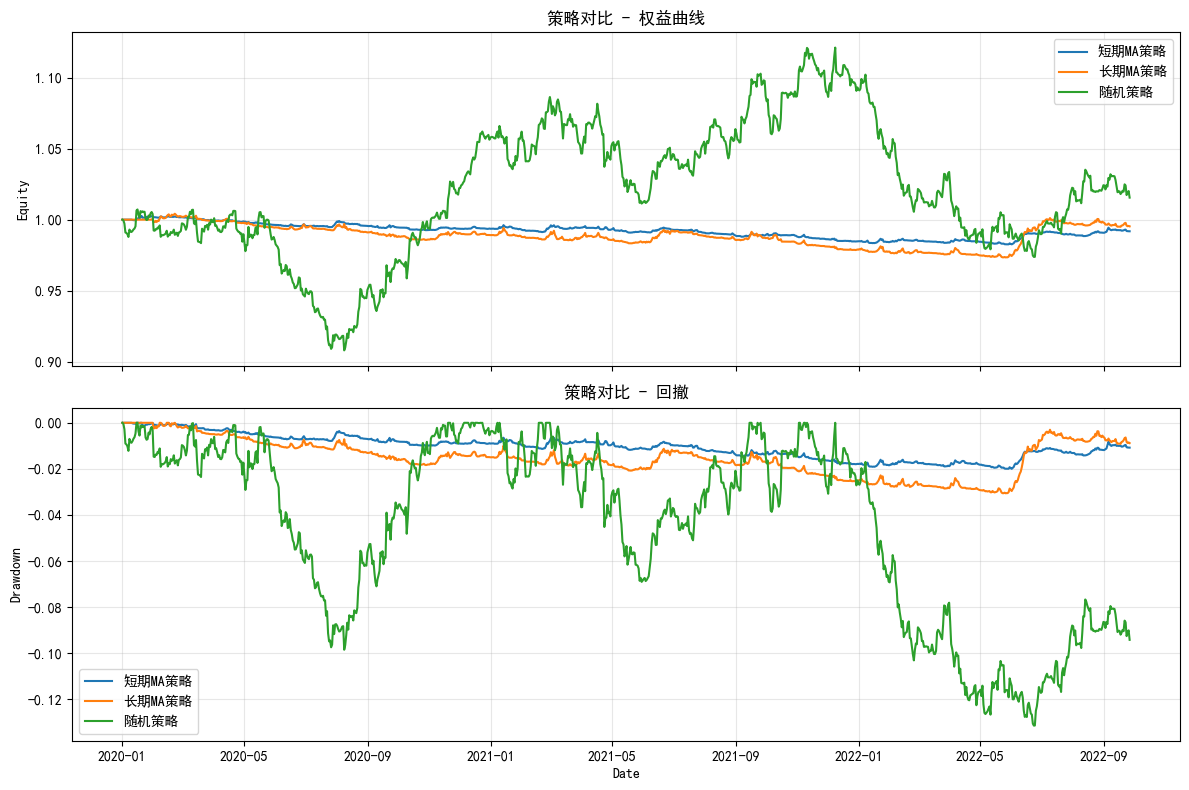

In [9]:
# 绘制批量对比图
SimpleBacktester.plot_comparison(batch_result)


In [10]:
# 查看详细的时间序列数据
print("权益曲线前10天:")
print(result.equity_curve.head(10))
print("\n权益曲线后10天:")
print(result.equity_curve.tail(10))
print("\n每日收益统计:")
print(result.daily_returns.describe())
print("\n仓位统计:")
print(result.position.describe())
print("\n换手率统计:")
print(result.turnover.describe())


权益曲线前10天:
2020-01-01    1.0
2020-01-02    1.0
2020-01-03    1.0
2020-01-04    1.0
2020-01-05    1.0
2020-01-06    1.0
2020-01-07    1.0
2020-01-08    1.0
2020-01-09    1.0
2020-01-10    1.0
Freq: D, Name: Lead_Price, dtype: float64

权益曲线后10天:
2022-09-17    0.994972
2022-09-18    0.995810
2022-09-19    0.995989
2022-09-20    0.996546
2022-09-21    0.997461
2022-09-22    0.997747
2022-09-23    0.995796
2022-09-24    0.995358
2022-09-25    0.995601
2022-09-26    0.995303
Freq: D, Name: Lead_Price, dtype: float64

每日收益统计:
count    1000.000000
mean       -0.000004
std         0.000654
min        -0.003079
25%        -0.000244
50%        -0.000003
75%         0.000185
max         0.002913
Name: Lead_Price, dtype: float64

仓位统计:
count    1000.000000
mean        0.004999
std         0.045037
min        -0.098660
25%        -0.025349
50%         0.000099
75%         0.030336
max         0.156751
Name: Lead_Price, dtype: float64

换手率统计:
count    1000.000000
mean        0.011296
std         0.009

In [11]:
# 测试止损止盈功能
# 重新运行回测，这次加入止损和止盈
result_with_sl_tp = bt.run(
    signal,
    stop_loss=0.15,  # 15% 止损
    take_profit=0.30  # 30% 止盈
)

print("带止损止盈的回测结果:")
SimpleBacktester.display_results(result_with_sl_tp)


带止损止盈的回测结果:

回测结果: BacktestStats(total_return=-0.0046966915219109895, annual_return=-0.0011856509796374093, annual_vol=0.010385238359662968, sharpe=-0.11416694914221374, max_drawdown=-0.030606560237186997, avg_turnover=0.011295769778101799, n_days=1000, annual_return_gross=0.00023698516228298772, annual_vol_gross=0.010381237921758022, sharpe_gross=0.022828217989907622, max_drawdown_gross=-0.025960522705130606, margin=0.034910471094635465, calmar_ratio=-0.03873845902476954, sortino_ratio=-0.14985681012386387, win_rate=0.462, profit_loss_ratio=1.0759507404739408, max_consecutive_losses=9, max_consecutive_wins=8)

【核心指标】
  总收益: -0.47%
  年化收益 (Net/Gross): -0.12% / 0.02%
  年化波动率 (Net/Gross): 1.04% / 1.04%
  Sharpe 比率 (Net/Gross): -0.114 / 0.023
  最大回撤 (Net/Gross): -3.06% / -2.60%

【风险指标】
  Calmar 比率: -0.039
  Sortino 比率: -0.150
  最大连续亏损: 9 天
  最大连续盈利: 8 天

【交易统计】
  胜率: 46.20%
  盈亏比: 1.076
  平均换手率: 0.0113
  保证金占用: 3.49%
  回测天数: 1000



对比表:
       Total Return  Annual Return (Net)  Annual Return (Gross)  \
无止损止盈     -0.004697            -0.001186               0.000237   
有止损止盈     -0.004697            -0.001186               0.000237   

       Annual Vol (Net)  Annual Vol (Gross)  Sharpe (Net)  Sharpe (Gross)  \
无止损止盈          0.010385            0.010381     -0.114167        0.022828   
有止损止盈          0.010385            0.010381     -0.114167        0.022828   

       Max Drawdown (Net)  Max Drawdown (Gross)  Calmar Ratio  Sortino Ratio  \
无止损止盈           -0.030607             -0.025961     -0.038738      -0.149857   
有止损止盈           -0.030607             -0.025961     -0.038738      -0.149857   

       Win Rate  Profit/Loss Ratio  Max Consecutive Losses  \
无止损止盈     0.462           1.075951                     9.0   
有止损止盈     0.462           1.075951                     9.0   

       Max Consecutive Wins  Avg Turnover   Margin  N Days  
无止损止盈                   8.0      0.011296  0.03491  1000.0  
有止损止盈     

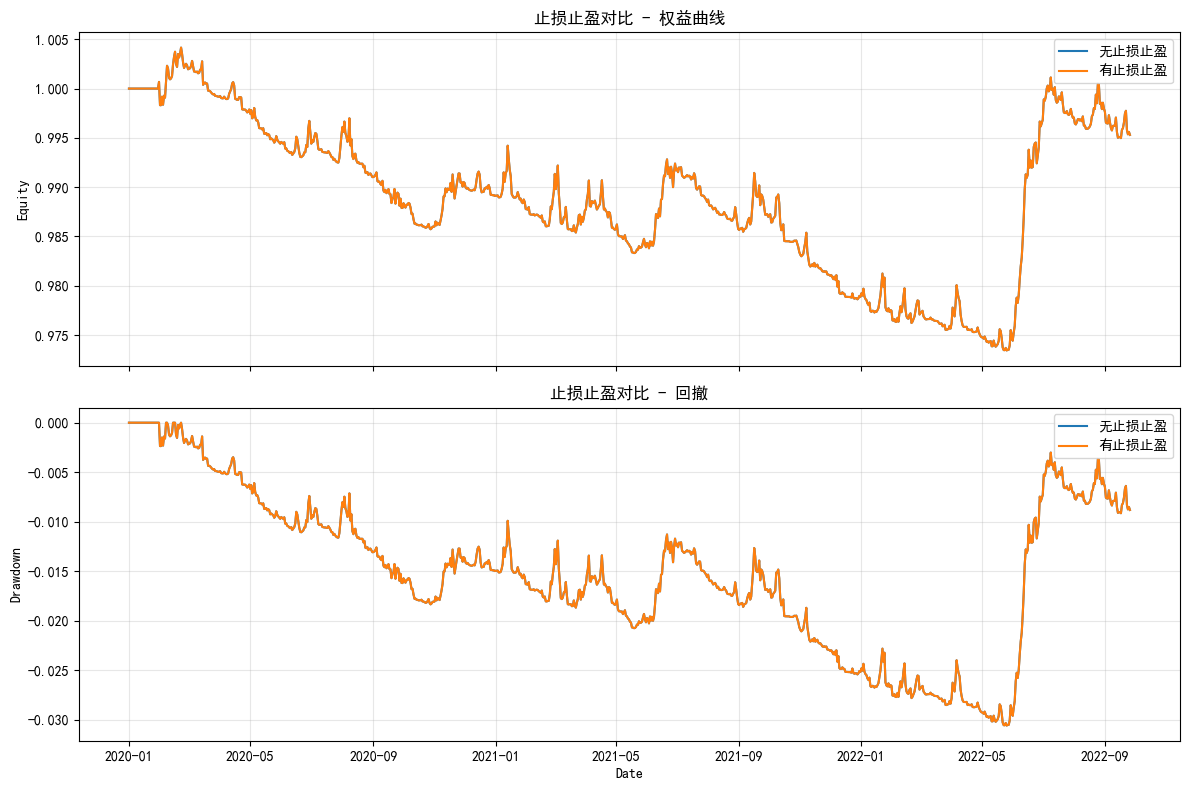

In [12]:
# 对比有无止损止盈
comparison_data = {
    '无止损止盈': SimpleBacktester.summarize(result),
    '有止损止盈': SimpleBacktester.summarize(result_with_sl_tp)
}
comparison_df = pd.DataFrame(comparison_data)
print("\n对比表:")
print(comparison_df.T)

# 绘制对比图
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(result.equity_curve.index, result.equity_curve.values, 
            label="无止损止盈", linewidth=1.5)
axes[0].plot(result_with_sl_tp.equity_curve.index, result_with_sl_tp.equity_curve.values, 
            label="有止损止盈", linewidth=1.5)
axes[0].set_ylabel("Equity")
axes[0].set_title("止损止盈对比 - 权益曲线")
axes[0].grid(alpha=0.3)
axes[0].legend()

dd1 = result.equity_curve / result.equity_curve.cummax() - 1.0
dd2 = result_with_sl_tp.equity_curve / result_with_sl_tp.equity_curve.cummax() - 1.0
axes[1].plot(dd1.index, dd1.values, label="无止损止盈", linewidth=1.5)
axes[1].plot(dd2.index, dd2.values, label="有止损止盈", linewidth=1.5)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_title("止损止盈对比 - 回撤")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
